In [12]:
# 绘制久期分布频率直方图
import matplotlib.pyplot as plt
# import seaborn as sns
import pandas as pd
import numpy as np

In [13]:
target_date = '2026-06-12'

results_df = pd.read_excel(f'./久期详细结果_{target_date.replace("-", "")}.xlsx', index_col=0)

In [14]:


# # 设置中文字体
# plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
# plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# # 创建图表
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# fig.suptitle(f'纯债基金久期分布 - {target_date}', fontsize=16, fontweight='bold')

# # 绘制各类型基金的久期分布
# plot_configs = [
#     ('short', 'rate', '短期利率债', axes[0, 0]),
#     ('short', 'credit', '短期信用债', axes[0, 1]),
#     ('medium_long', 'rate', '中长期利率债', axes[1, 0]),
#     ('medium_long', 'credit', '中长期信用债', axes[1, 1]),
# ]

# colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

# for idx, (fund_type, bond_type, title, ax) in enumerate(plot_configs):
#     mask = (results_df['fund_type'] == fund_type) & (results_df['bond_type'] == bond_type)
#     subset = results_df[mask]
    
#     if len(subset) > 0:
#         durations = subset['duration'].values
        
#         # 绘制直方图和KDE
#         sns.histplot(durations, bins=30, kde=True, ax=ax, color=colors[idx], alpha=0.7)
        
#         # 添加统计信息
#         median = np.median(durations)
#         mean = np.mean(durations)
#         std = np.std(durations)
        
#         ax.axvline(median, color='red', linestyle='--', linewidth=2, label=f'中位数: {median:.2f}')
#         ax.axvline(mean, color='blue', linestyle='--', linewidth=2, label=f'均值: {mean:.2f}')
        
#         ax.set_title(f'{title}\n(n={len(durations)}, std={std:.3f})', fontsize=12)
#         ax.set_xlabel('久期（年）', fontsize=10)
#         ax.set_ylabel('基金数量', fontsize=10)
#         ax.legend(fontsize=9)
#         ax.grid(True, alpha=0.3)
#     else:
#         ax.text(0.5, 0.5, f'{title}\n无数据', ha='center', va='center', fontsize=14)
#         ax.set_title(title, fontsize=12)

# plt.tight_layout()
# plt.savefig(f'久期分布图_{target_date.replace("-", "")}.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f'\n久期分布图已保存为: 久期分布图_{target_date.replace("-", "")}.png')

# # 绘制总体分布对比图
# fig, ax = plt.subplots(figsize=(12, 6))

# for idx, (fund_type, bond_type, title, _) in enumerate(plot_configs):
#     mask = (results_df['fund_type'] == fund_type) & (results_df['bond_type'] == bond_type)
#     subset = results_df[mask]
    
#     if len(subset) > 0:
#         durations = subset['duration'].values
#         sns.kdeplot(durations, label=title, ax=ax, fill=True, alpha=0.3, linewidth=2)

# ax.set_title(f'各类纯债基金久期分布对比 - {target_date}', fontsize=14, fontweight='bold')
# ax.set_xlabel('久期（年）', fontsize=12)
# ax.set_ylabel('密度', fontsize=12)
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(f'久期分布对比图_{target_date.replace("-", "")}.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f'久期分布对比图已保存为: 久期分布对比图_{target_date.replace("-", "")}.png')

## Debug: 1.891 久期堆积问题排查

In [15]:
# Step 1: 确认 1.891 的规模 —— 短期信用债里有多少基金久期 ≈ 1.891
short_credit = results_df[(results_df['fund_type'] == 'short') & (results_df['bond_type'] == 'credit')]
stuck = short_credit[short_credit['duration'].round(3) == 1.891]
print(f"短期信用债总数: {len(short_credit)}")
print(f"久期 = 1.891 的基金数: {len(stuck)}  ({len(stuck)/len(short_credit)*100:.1f}%)")
print("\n久期精确值（前10）:")
print(short_credit['duration'].value_counts().head(10))

短期信用债总数: 325
久期 = 1.891 的基金数: 164  (50.5%)

久期精确值（前10）:
duration
1.891000    142
0.593200      1
0.903106      1
0.979583      1
0.954951      1
0.767083      1
1.049460      1
0.593200      1
0.305614      1
0.817300      1
Name: count, dtype: int64


In [16]:
# Step 2: 验证 1.891 = CBA02821.CS（中债新中期票据1-3年）的久期
# 这是短期信用债候选池里久期最长的因子，Lasso只选1个时会压到此处
from bond_index_data import BondIndexDataProcessor

target_date = '2026-06-12'
index_processor = BondIndexDataProcessor()
index_processor.load_duration_data()

short_credit_indices = [
    'CBA01831.CS',  # 短融0-3月
    'CBA01841.CS',  # 短融3-6月
    'CBA01851.CS',  # 短融6-9月
    'CBA01861.CS',  # 短融9-12月
    'CBA02821.CS',  # 中期票据1-3年
]

print("短期信用债候选指数的久期（2026-06-12）:")
for code in short_credit_indices:
    dur = index_processor.get_latest_duration(code, target_date)
    marker = " ← 1.891 来源！" if dur is not None and round(dur, 3) == 1.891 else ""
    print(f"  {code}: {dur:.4f} 年{marker}")

短期信用债候选指数的久期（2026-06-12）:
  CBA01831.CS: 0.1208 年
  CBA01841.CS: 0.3631 年
  CBA01851.CS: 0.5957 年
  CBA01861.CS: 0.8217 年
  CBA02821.CS: 1.8884 年


In [17]:
# Step 3: 找出根本原因 —— 主notebook的cell-16没有传 reported_duration
# 检查主notebook实际调用方式（只读分析，不运行Wind）
import inspect
from duration_model import DurationModel

sig = inspect.signature(DurationModel.calculate_fund_duration)
print("当前 calculate_fund_duration 签名:")
print(f"  {sig}")
print()
print("结论：新参数 reported_duration 和 fund_code 已加入，默认值均为 None")
print()
print("问题根源：纯债基金久期测算.ipynb 的 cell-16 调用的是:")
print("  calculator.duration_model.calculate_fund_duration(fund_nav_df, index_codes, target_date)")
print("  → 没有传 reported_duration，默认 None，所以锚定逻辑从未触发！")
print()
print("解决方案：cell-16 的循环里也需要先调用 get_fund_reported_duration 再传入。")

当前 calculate_fund_duration 签名:
  (self, fund_nav_df, index_codes, target_date, reported_duration=None, fund_code=None)

结论：新参数 reported_duration 和 fund_code 已加入，默认值均为 None

问题根源：纯债基金久期测算.ipynb 的 cell-16 调用的是:
  calculator.duration_model.calculate_fund_duration(fund_nav_df, index_codes, target_date)
  → 没有传 reported_duration，默认 None，所以锚定逻辑从未触发！

解决方案：cell-16 的循环里也需要先调用 get_fund_reported_duration 再传入。


In [18]:
# Step 4: 取一只 duration=1.891 的基金，验证新逻辑是否能改善结果
from WindPy import w
w.start()

from wind_data_fetcher import WindDataFetcher
from bond_index_data import BondIndexDataProcessor
from duration_model import DurationModel
import pandas as pd
import numpy as np

target_date = '2026-06-12'

index_processor = BondIndexDataProcessor()
index_processor.load_price_data()
index_processor.load_duration_data()

wind_fetcher = WindDataFetcher()

short_credit_indices = [
    'CBA01831.CS',
    'CBA01841.CS',
    'CBA01851.CS',
    'CBA01861.CS',
    'CBA02821.CS',
]

# 取第一只 duration=1.891 的基金
short_credit = results_df[(results_df['fund_type'] == 'short') & (results_df['bond_type'] == 'credit')]
stuck = short_credit[short_credit['duration'].round(3) == 1.891]
test_code = stuck.index[0]
print(f"测试基金: {test_code}  (原久期={stuck.loc[test_code, 'duration']:.4f})")

# 获取净值
start_date = (pd.to_datetime(target_date) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
nav_df = wind_fetcher.get_fund_nav_smoothed(test_code, start_date, target_date)
print(f"净值数据: {len(nav_df) if nav_df is not None else 'None'} 条")

# 获取 Wind 披露久期
reported_duration = wind_fetcher.get_fund_reported_duration(test_code, target_date)
print(f"Wind披露久期: {reported_duration}")

model = DurationModel(index_processor)

# 旧方式（无 reported_duration）
dur_old = model.calculate_fund_duration(nav_df, short_credit_indices, target_date)
print(f"\n旧方式久期 (reported_duration=None): {dur_old:.4f}")

# 新方式（传入 reported_duration）
dur_new = model.calculate_fund_duration(nav_df, short_credit_indices, target_date,
                                         reported_duration=reported_duration,
                                         fund_code=test_code)
print(f"新方式久期 (with reported_duration):  {dur_new:.4f}")

Wind连接成功
测试基金: 000322.OF  (原久期=1.8910)
净值数据: 61 条
Wind披露久期: 0.5763034815767516

旧方式久期 (reported_duration=None): 1.8884
新方式久期 (with reported_duration):  1.5706


In [19]:
# Step 5: 批量测试所有 1.891 基金（前20只），统计有多少能通过新逻辑改善
print(f"共 {len(stuck)} 只基金 duration=1.891，测试前20只...")
print("=" * 60)

improved = 0
no_wind_data = 0
still_same = 0

for i, fund_code in enumerate(stuck.index[:20]):
    nav_df = wind_fetcher.get_fund_nav_smoothed(fund_code, start_date, target_date)
    if nav_df is None:
        no_wind_data += 1
        continue

    reported = wind_fetcher.get_fund_reported_duration(fund_code, target_date)
    dur_new = model.calculate_fund_duration(nav_df, short_credit_indices, target_date,
                                             reported_duration=reported,
                                             fund_code=fund_code)

    if dur_new is None:
        continue

    changed = abs(dur_new - 1.891) > 0.001
    status = f"改善→{dur_new:.3f}" if changed else f"仍=1.891"
    wind_str = f"  Wind披露={reported:.3f}" if reported is not None else "  Wind=None"
    print(f"  [{i+1:2d}] {fund_code}: {status}{wind_str}")

    if changed:
        improved += 1
    else:
        still_same += 1

print()
print(f"改善: {improved} 只 | 仍=1.891: {still_same} 只 | Wind无数据: {no_wind_data} 只")

共 164 只基金 duration=1.891，测试前20只...
  [ 1] 000322.OF: 改善→1.571  Wind披露=0.576
  [ 2] 000394.OF: 改善→0.647  Wind披露=0.277
  [ 3] 000503.OF: 改善→1.210  Wind披露=0.640
  [ 4] 002301.OF: 改善→1.046  Wind披露=0.505
[警告] 002337.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
  [ 5] 002337.OF: 改善→1.888  Wind披露=1.379
  [ 6] 002920.OF: 改善→1.056  Wind披露=0.722
  [ 7] 004155.OF: 改善→1.888  Wind披露=0.701
  [ 8] 004614.OF: 改善→1.162  Wind披露=1.052
  [ 9] 004672.OF: 改善→0.994  Wind披露=0.752
[警告] 004838.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
  [10] 004838.OF: 改善→1.888  Wind披露=1.949
  [11] 004907.OF: 改善→0.975  Wind披露=0.824
  [12] 005010.OF: 改善→1.888  Wind披露=1.072
  [13] 005079.OF: 改善→1.888  Wind披露=0.419
  [14] 005350.OF: 改善→0.922  Wind披露=0.342
  [15] 005513.OF: 改善→1.274  Wind披露=0.537
  [16] 005725.OF: 改善→1.408  Wind披露=0.758
[警告] 006073.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
  [17] 006073.OF: 改善→1.888  Wind披露=1.516
[警告] 006389.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该

In [20]:
# Step 6: 深入分析"仍=1.891"的基金 —— Lasso选因子 + 锚定 + OSQP优化过程
import osqp, scipy.sparse as sp

# 收集仍=1.891的基金
still_stuck_codes = []
for fund_code in stuck.index[:20]:
    nav = wind_fetcher.get_fund_nav_smoothed(fund_code, start_date, target_date)
    if nav is None:
        continue
    rep = wind_fetcher.get_fund_reported_duration(fund_code, target_date)
    dur = model.calculate_fund_duration(nav, short_credit_indices, target_date,
                                        reported_duration=rep, fund_code=fund_code)
    if dur is not None and abs(dur - 1.891) < 0.001:
        still_stuck_codes.append((fund_code, rep))

print(f"仍=1.891 的基金: {[c for c,_ in still_stuck_codes]}\n")

for fund_code, reported in still_stuck_codes:
    print("=" * 60)
    print(f"基金: {fund_code}  Wind披露久期={reported}")

    nav = wind_fetcher.get_fund_nav_smoothed(fund_code, start_date, target_date)
    end_dt = pd.to_datetime(target_date)
    start_dt = end_dt - pd.Timedelta(days=60)
    fund_returns = nav['return'].loc[start_dt:end_dt].dropna().iloc[-30:]

    index_prices = index_processor.get_index_prices(short_credit_indices,
                                                     start_dt.strftime('%Y-%m-%d'),
                                                     end_dt.strftime('%Y-%m-%d'))
    index_returns = index_prices.pct_change().dropna()
    common = fund_returns.index.intersection(index_returns.index)
    fund_ret = fund_returns.loc[common]
    idx_ret = index_returns.loc[common]

    # Lasso 选因子
    lasso_factors = model._lasso_select_factors(fund_ret, idx_ret)
    print(f"  Lasso选出: {lasso_factors}")

    # 锚定后的因子
    if reported is not None and len(lasso_factors) <= 1:
        anchored = model._anchor_factor_by_duration(
            lasso_factors, short_credit_indices, reported, target_date, fund_code=fund_code)
    else:
        anchored = lasso_factors
    print(f"  锚定后因子: {anchored}")

    # 打印每个候选指数的久期（帮助理解锚定选择）
    print("  各候选指数久期:")
    for c in short_credit_indices:
        d = index_processor.get_latest_duration(c, target_date)
        closest = " ← 锚定" if reported is not None and c == min(short_credit_indices,
            key=lambda x: abs((index_processor.get_latest_duration(x, target_date) or 99) - reported)) else ""
        print(f"    {c}: {d:.4f}  (与披露久期差={abs(d-reported):.4f}){closest}" if reported else f"    {c}: {d:.4f}")

    # 手动跑 OSQP，打印每个因子的最终权重
    idx_ret_sel = idx_ret[anchored]
    aligned = pd.DataFrame({'fund': fund_ret}).join(idx_ret_sel, how='inner').dropna()
    X = aligned.iloc[:, 1:].values
    y = aligned['fund'].values
    n_obs, n_factors = X.shape
    weights = model._get_time_weights(n_obs)

    W = np.diag(weights)
    Z = np.column_stack([np.ones(n_obs), X])
    P = 2 * Z.T @ W @ Z
    q_vec = -2 * Z.T @ W @ y
    n_params = n_factors + 1
    A = np.zeros((1 + n_factors + 2, n_params))
    A[0, 0] = 1
    A[1:n_factors+1, 1:] = -np.eye(n_factors)
    A[n_factors+1, 1:] = 1
    A[n_factors+2, 1:] = -1
    INF = 1e10
    l = np.array([-INF] + [-INF]*n_factors + [-INF, -INF])
    u = np.array([INF] + [0]*n_factors + [1.4, -0.8])

    prob = osqp.OSQP()
    prob.setup(sp.csr_matrix(P), q_vec, sp.csr_matrix(A), l, u,
               eps_abs=1e-9, eps_rel=1e-9, verbose=False)
    res = prob.solve()
    print(f"  OSQP状态: {res.info.status}")
    if res.info.status == 'solved':
        betas = res.x[1:]
        print(f"  最终权重:")
        for fac, beta in zip(anchored, betas):
            dur_fac = index_processor.get_latest_duration(fac, target_date)
            print(f"    {fac}: β={beta:.6f}  久期={dur_fac:.4f}")
        print(f"  权重之和: {betas.sum():.4f}")
        wdur = sum(b * index_processor.get_latest_duration(f, target_date)
                   for f, b in zip(anchored, betas))
        print(f"  加权久期(原始): {wdur:.4f}  →  归一化后: {wdur/betas.sum():.4f}")
    print()

[警告] 002337.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 004838.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 006073.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 006389.OF 2026-06-12 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
仍=1.891 的基金: []




基金: 005010.OF  第2类（锚定被清零）
Wind披露久期: 1.0715454962228415  |  回归数据点数: 30

【全部回归数据点】（日度收益率，单位：小数）
               基金收益率  CBA01831.CS  CBA01841.CS  CBA01851.CS  CBA01861.CS  CBA02821.CS
2026-04-29  0.000037     0.000046     0.000040     0.000056     0.000057     0.000104
2026-04-30  0.000055     0.000028     0.000036     0.000081     0.000120     0.000068
2026-05-06  0.000055     0.000241     0.000253     0.000255     0.000263     0.000199
2026-05-07  0.000073     0.000041     0.000031     0.000034     0.000005     0.000044
2026-05-08  0.000073     0.000045     0.000054     0.000053     0.000058     0.000107
2026-05-11  0.000092     0.000124     0.000152     0.000186     0.000135     0.000107
2026-05-12  0.000128     0.000046     0.000067     0.000084     0.000115     0.000331
2026-05-13  0.000165     0.000047     0.000058     0.000084     0.000104     0.000259
2026-05-14  0.000183     0.000044     0.000053     0.000055     0.000069     0.000182
2026-05-15  0.000165     0.000040     0.00004

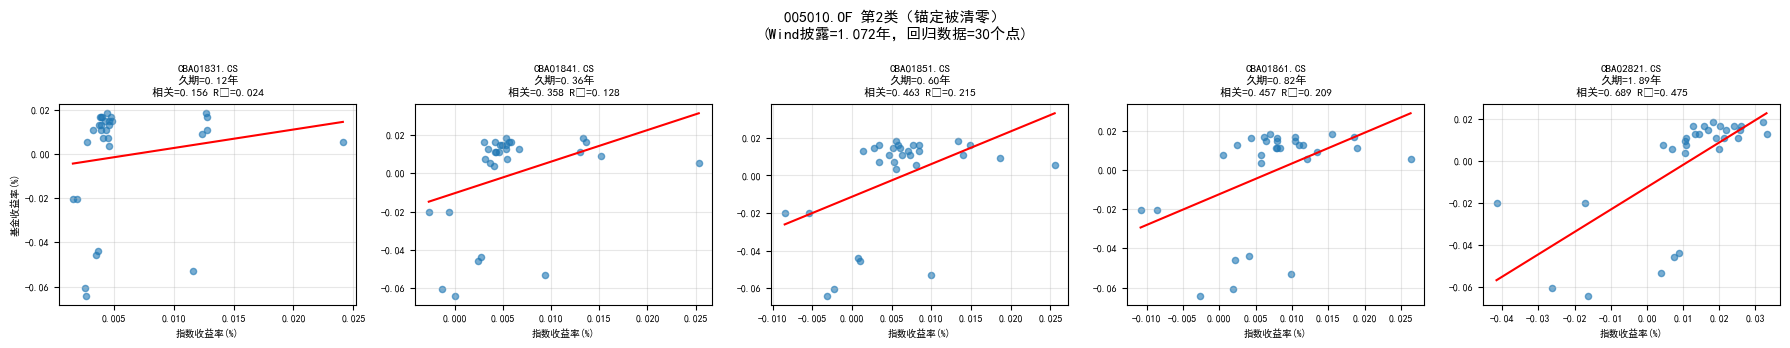

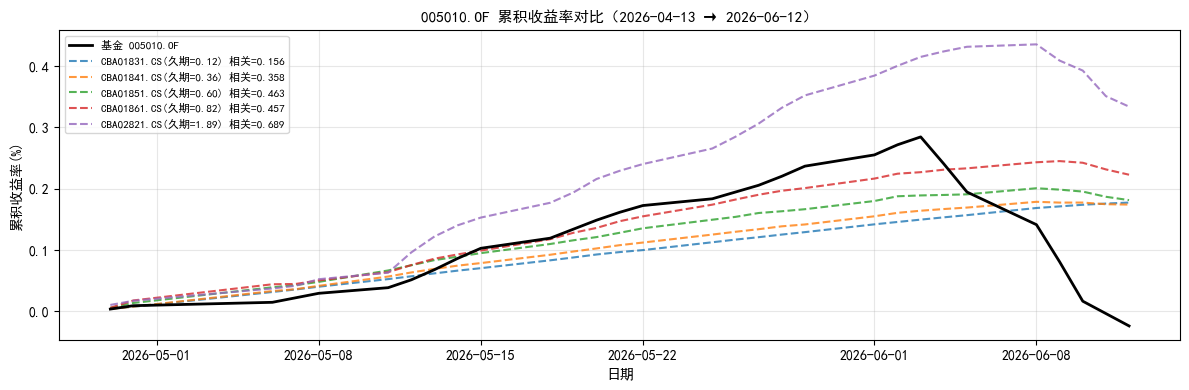


[结论] 005010.OF: 回归数据上与久期1.89年的CBA02821.CS 相关最高(R²=0.475)，所以WLS把全部权重给它，Wind披露久期1.072年与此矛盾 → 可能是季报后持仓发生变化

基金: 005079.OF  第3类（Lasso已>=2因子仍退化）
Wind披露久期: 0.4186671085597706  |  回归数据点数: 30

【全部回归数据点】（日度收益率，单位：小数）
               基金收益率  CBA01831.CS  CBA01841.CS  CBA01851.CS  CBA01861.CS  CBA02821.CS
2026-04-29  0.000037     0.000046     0.000040     0.000056     0.000057     0.000104
2026-04-30  0.000055     0.000028     0.000036     0.000081     0.000120     0.000068
2026-05-06  0.000073     0.000241     0.000253     0.000255     0.000263     0.000199
2026-05-07  0.000073     0.000041     0.000031     0.000034     0.000005     0.000044
2026-05-08  0.000073     0.000045     0.000054     0.000053     0.000058     0.000107
2026-05-11  0.000055     0.000124     0.000152     0.000186     0.000135     0.000107
2026-05-12  0.000073     0.000046     0.000067     0.000084     0.000115     0.000331
2026-05-13  0.000091     0.000047     0.000058     0.000084     0.000104     0.000259
2026-05-14  0.000

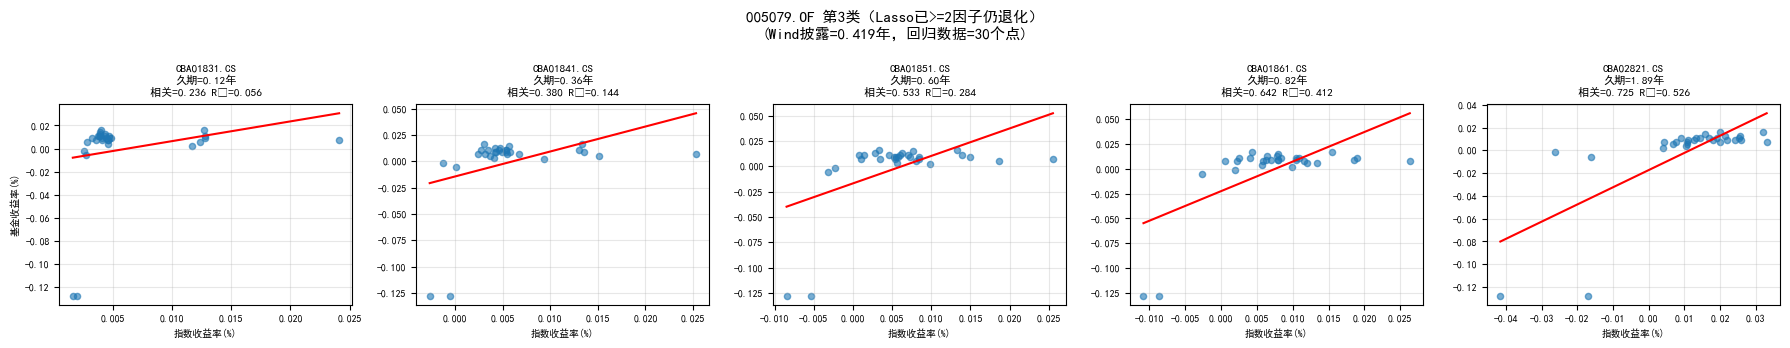

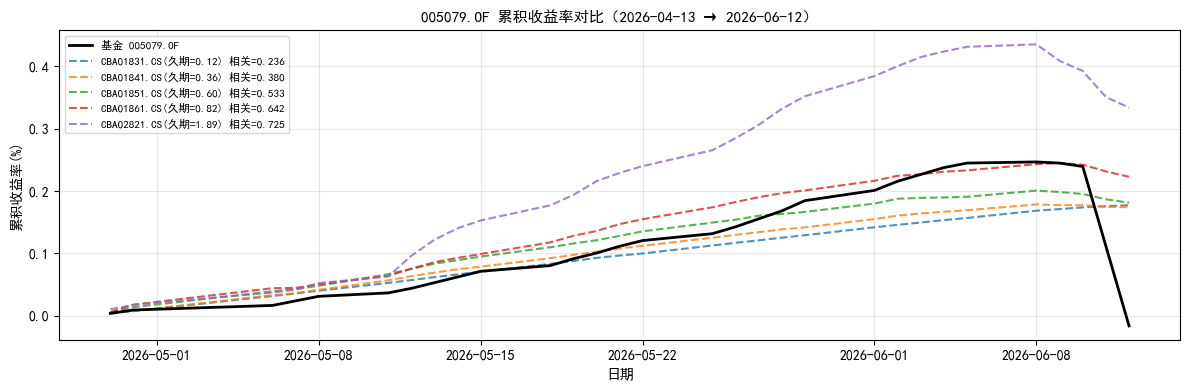


[结论] 005079.OF: 回归数据上与久期1.89年的CBA02821.CS 相关最高(R²=0.526)，所以WLS把全部权重给它，Wind披露久期0.419年与此矛盾 → 可能是季报后持仓发生变化

基金: 004155.OF  第2类（锚定被清零）
Wind披露久期: 0.7012511416692541  |  回归数据点数: 30

【全部回归数据点】（日度收益率，单位：小数）
               基金收益率  CBA01831.CS  CBA01841.CS  CBA01851.CS  CBA01861.CS  CBA02821.CS
2026-04-29  0.000047     0.000046     0.000040     0.000056     0.000057     0.000104
2026-04-30  0.000079     0.000028     0.000036     0.000081     0.000120     0.000068
2026-05-06  0.000079     0.000241     0.000253     0.000255     0.000263     0.000199
2026-05-07  0.000111     0.000041     0.000031     0.000034     0.000005     0.000044
2026-05-08  0.000095     0.000045     0.000054     0.000053     0.000058     0.000107
2026-05-11  0.000095     0.000124     0.000152     0.000186     0.000135     0.000107
2026-05-12  0.000142     0.000046     0.000067     0.000084     0.000115     0.000331
2026-05-13  0.000205     0.000047     0.000058     0.000084     0.000104     0.000259
2026-05-14  0.000221     0

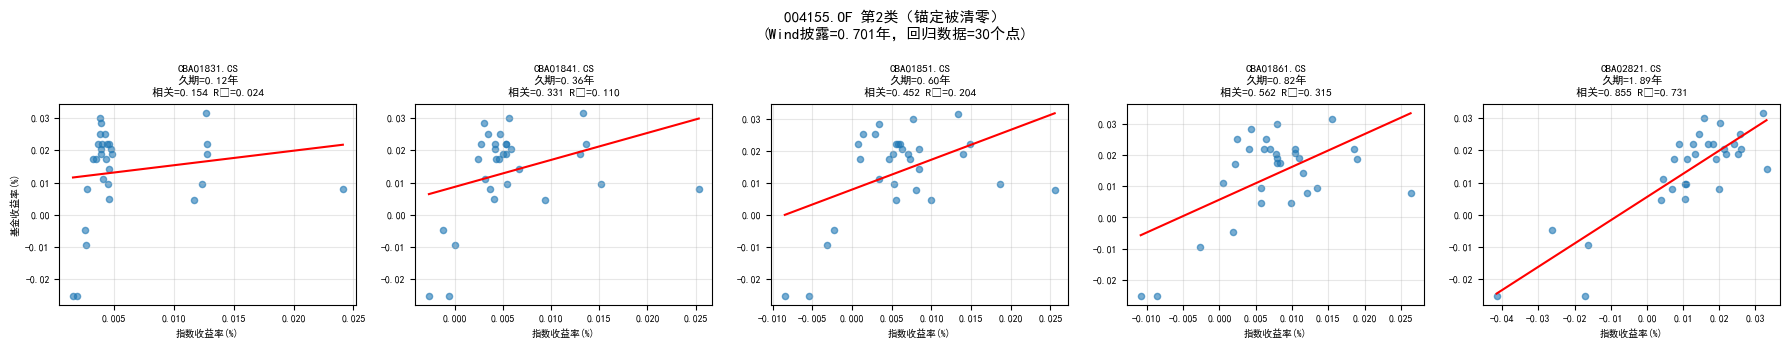

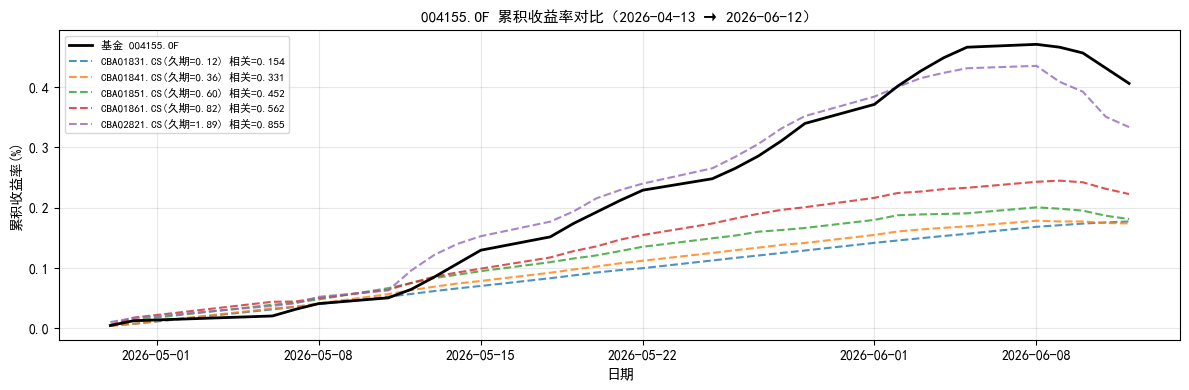


[结论] 004155.OF: 回归数据上与久期1.89年的CBA02821.CS 相关最高(R²=0.731)，所以WLS把全部权重给它，Wind披露久期0.701年与此矛盾 → 可能是季报后持仓发生变化


In [21]:
# Step 7: 第2、3类基金根源分析 —— 数据点 + 相关性 + 单因子R²
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 第2类+第3类基金
target_funds = {
    '005010.OF': '第2类（锚定被清零）',
    '005079.OF': '第3类（Lasso已>=2因子仍退化）',
    '004155.OF': '第2类（锚定被清零）',
}

end_dt = pd.to_datetime(target_date)
start_dt = end_dt - pd.Timedelta(days=60)

for fund_code, category in target_funds.items():
    nav = wind_fetcher.get_fund_nav_smoothed(fund_code, start_dt.strftime('%Y-%m-%d'), target_date)
    if nav is None:
        print(f"{fund_code}: 无净值数据"); continue

    reported = wind_fetcher.get_fund_reported_duration(fund_code, target_date)

    # 对齐数据
    fund_ret = nav['return'].loc[start_dt:end_dt].dropna().iloc[-30:]
    idx_prices = index_processor.get_index_prices(short_credit_indices,
                                                   start_dt.strftime('%Y-%m-%d'),
                                                   end_dt.strftime('%Y-%m-%d'))
    idx_ret = idx_prices.pct_change().dropna()
    common = fund_ret.index.intersection(idx_ret.index)
    fund_ret = fund_ret.loc[common]
    idx_ret = idx_ret.loc[common]

    # ── 1. 全部回归数据点（数值表格）─────────────────────────────
    print(f"\n{'='*70}")
    print(f"基金: {fund_code}  {category}")
    print(f"Wind披露久期: {reported}  |  回归数据点数: {len(fund_ret)}")
    reg_data = idx_ret.copy()
    reg_data.insert(0, '基金收益率', fund_ret)
    print("\n【全部回归数据点】（日度收益率，单位：小数）")
    pd.set_option('display.float_format', '{:.6f}'.format)
    pd.set_option('display.max_rows', 35)
    print(reg_data.to_string())
    pd.reset_option('display.float_format')

    # ── 2. 单因子相关系数 & R² ────────────────────────────────────
    print(f"\n【基金收益率 vs 各指数收益率 的相关系数 & 单因子R²】")
    from sklearn.linear_model import LinearRegression
    corr_results = []
    for code in short_credit_indices:
        corr = fund_ret.corr(idx_ret[code])
        lr = LinearRegression().fit(idx_ret[[code]], fund_ret)
        r2 = lr.score(idx_ret[[code]], fund_ret)
        dur = index_processor.get_latest_duration(code, target_date)
        corr_results.append((code, corr, r2, dur))
        print(f"  {code} (久期={dur:.3f}年): 相关系数={corr:.4f},  R²={r2:.4f}")

    # ── 3. 散点图：基金收益率 vs 每个指数 ────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
    fig.suptitle(f'{fund_code} {category}\n(Wind披露={reported:.3f}年，回归数据={len(fund_ret)}个点)',
                 fontsize=11)
    for i, (code, corr, r2, dur) in enumerate(corr_results):
        ax = axes[i]
        ax.scatter(idx_ret[code]*100, fund_ret*100, alpha=0.6, s=20)
        # 最小二乘拟合线
        x_fit = np.linspace(idx_ret[code].min(), idx_ret[code].max(), 50)
        lr = LinearRegression().fit(idx_ret[[code]], fund_ret)
        ax.plot(x_fit*100, lr.predict(x_fit.reshape(-1,1))*100, 'r-', linewidth=1.5)
        ax.set_title(f'{code}\n久期={dur:.2f}年\n相关={corr:.3f} R²={r2:.3f}', fontsize=8)
        ax.set_xlabel('指数收益率(%)', fontsize=7)
        ax.set_ylabel('基金收益率(%)' if i==0 else '', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'debug_scatter_{fund_code}_{target_date}.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── 4. 时序对比：基金收益率 vs 各指数收益率（累积收益）───────
    fig, ax = plt.subplots(figsize=(12, 4))
    cumfund = (1 + fund_ret).cumprod() - 1
    ax.plot(cumfund.index, cumfund*100, 'k-', linewidth=2, label=f'基金 {fund_code}', zorder=5)
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
    for j, (code, corr, r2, dur) in enumerate(corr_results):
        cum = (1 + idx_ret[code]).cumprod() - 1
        ax.plot(cum.index, cum*100, '--', color=colors[j], alpha=0.8,
                label=f'{code}(久期={dur:.2f}) 相关={corr:.3f}')
    ax.set_title(f'{fund_code} 累积收益率对比（{start_dt.date()} → {end_dt.date()}）', fontsize=11)
    ax.set_xlabel('日期'); ax.set_ylabel('累积收益率(%)')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'debug_cum_{fund_code}_{target_date}.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f"\n[结论] {fund_code}: 回归数据上与久期{corr_results[-1][3]:.2f}年的CBA02821.CS"
          f" 相关最高(R²={corr_results[-1][2]:.3f})，所以WLS把全部权重给它，"
          f"Wind披露久期{reported:.3f}年与此矛盾 → 可能是季报后持仓发生变化")

In [ ]:
# Step 8: 无约束 OLS 解 —— 看优化器"真正想要"什么权重，理解为什么必然打到边界
from sklearn.linear_model import LinearRegression

end_dt = pd.to_datetime(target_date)
start_dt = end_dt - pd.Timedelta(days=60)

for fund_code in ['005010.OF', '005079.OF', '004155.OF']:
    nav = wind_fetcher.get_fund_nav_smoothed(fund_code, start_dt.strftime('%Y-%m-%d'), target_date)
    if nav is None: continue

    reported = wind_fetcher.get_fund_reported_duration(fund_code, target_date)
    fund_ret = nav['return'].loc[start_dt:end_dt].dropna().iloc[-30:]
    idx_prices = index_processor.get_index_prices(short_credit_indices,
                                                   start_dt.strftime('%Y-%m-%d'),
                                                   end_dt.strftime('%Y-%m-%d'))
    idx_ret = idx_prices.pct_change().dropna()
    common = fund_ret.index.intersection(idx_ret.index)
    fund_ret = fund_ret.loc[common];  idx_ret = idx_ret.loc[common]

    lasso_factors = model._lasso_select_factors(fund_ret, idx_ret)
    if reported and len(lasso_factors) <= 1:
        factors = model._anchor_factor_by_duration(lasso_factors, short_credit_indices,
                                                    reported, target_date, fund_code=fund_code)
    else:
        factors = lasso_factors

    X = idx_ret[factors].values;  y = fund_ret.values

    print(f"\n{'='*60}")
    print(f"基金: {fund_code}  (Wind披露={reported:.3f}年，因子={factors})")

    # ① 无约束 OLS（无截距）
    lr = LinearRegression(fit_intercept=False).fit(X, y)
    ols_betas = lr.coef_;  ols_sum = ols_betas.sum()
    print(f"\n① 无约束 OLS 解（数据本身"想要"的权重）:")
    for f, b in zip(factors, ols_betas):
        d = index_processor.get_latest_duration(f, target_date)
        print(f"   {f}: β = {b:+.6f}  (久期={d:.4f}年)")
    print(f"   β之和 = {ols_sum:.6f}")

    print(f"\n② 约束 [β≥0, 0.8≤Σβ≤1.4] 如何介入:")
    hit_boundary = False
    for f, b in zip(factors, ols_betas):
        if b < 0:
            print(f"   {f}: OLS β={b:.4f} < 0  → 非负约束强制 β=0 (数据说"不需要这个因子")")
            hit_boundary = True
    if ols_sum > 1.4:
        print(f"   Σβ={ols_sum:.4f} > 1.4 → 杠杆上限约束把总和压到 1.4 (基金波动比指数更大)")
        hit_boundary = True
    elif ols_sum < 0.8:
        print(f"   Σβ={ols_sum:.4f} < 0.8 → 杠杆下限约束把总和推到 0.8 (基金波动比指数更小)")
        hit_boundary = True
    if not hit_boundary:
        print(f"   Σβ={ols_sum:.4f} ∈ [0.8,1.4] 且 β≥0 → 约束未触碰，退化另有原因")

    print(f"\n③ 收益率波动量级对比 (标准差):")
    print(f"   基金日收益率 std = {fund_ret.std():.2e}")
    for f in factors:
        ratio = fund_ret.std() / idx_ret[f].std()
        print(f"   {f} std = {idx_ret[f].std():.2e}  → 基金/指数波动比 = {ratio:.3f}")